In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from two_swiss_rolls import two_swiss_rolls

seed = 42
np.random.seed(seed)
X, F = two_swiss_rolls(n_samples=2500, offset = 50.0, noise=2.0, outliers=0, seed=seed)
F_names = [r'$s_1$', r'$s_2$', r'$t_1$', r'$t_2$']

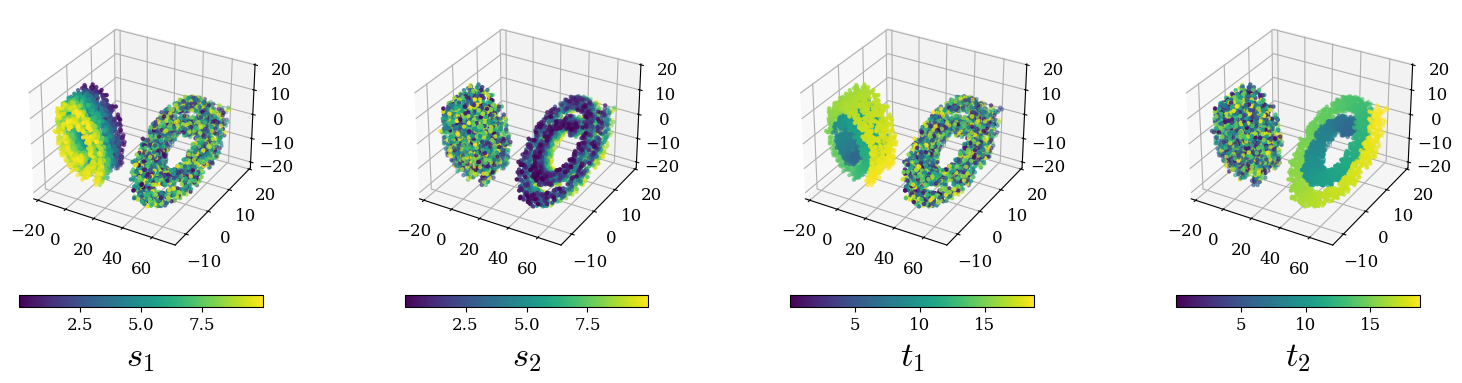

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12, 'font.family': 'serif', 'mathtext.fontset' : 'cm'})

fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(141, projection='3d')
sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=F[:, 0], s=5, cmap='viridis')
scbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, orientation='horizontal')
scbar.set_label(F_names[0], size=25)
ax = fig.add_subplot(142, projection='3d')
sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=F[:, 1], s=5, cmap='viridis')
scbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, orientation='horizontal')
scbar.set_label(F_names[1], size=25)
ax = fig.add_subplot(143, projection='3d')
sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=F[:, 2], s=5, cmap='viridis')
scbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, orientation='horizontal')
scbar.set_label(F_names[2], size=25)
ax = fig.add_subplot(144, projection='3d')
sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=F[:, 3], s=5, cmap='viridis')
scbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, orientation='horizontal')
scbar.set_label(F_names[3], size=25)
fig.tight_layout()
fig.savefig('../images/two_swiss_rolls.png', dpi=300, bbox_inches="tight")

In [ ]:
import sys
sys.path.append('../')
from lego import lego

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import MultiTaskElasticNet
from sklearn.neighbors import kneighbors_graph
from local_ts_regression import lpca, run_ts_regression_smoothed

d = 2

r = 1.0
knn = 8
neighbor_graph = kneighbors_graph(X, knn, include_self=True)

trivial_basis = np.stack([np.eye(X.shape[1])] * X.shape[0], axis=0)
lpca_basis = lpca(X, d, neighbor_graph)
wlpca_basis = lpca(X, d, neighbor_graph, r=1.0)

lego_estimate = lego.lego(
    X, opts={'emb_dim': d, 'k_nn': knn}
)
lego_basis = lego_estimate['tang_basis']

Support Features: ['s1', 's2']


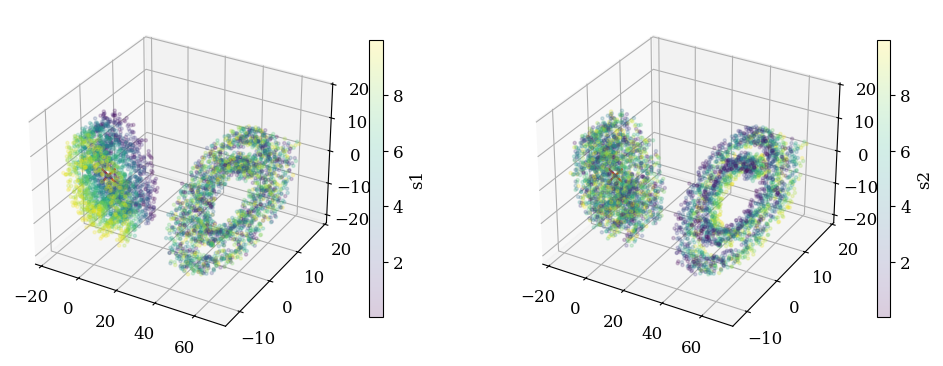

In [13]:
index = 0
# index = subset_indices[0]

# tsbasis = trivial_basis
# tsbasis = lpca_basis
# tsbasis = wlpca_basis
tsbasis = lego_basis

normalizer = StandardScaler(with_mean=False)
# regressor = LinearRegression(fit_intercept=False)
# regressor = MultiTaskLasso(alpha=0.0, fit_intercept=False)
regressor = MultiTaskElasticNet(alpha=0.5, l1_ratio=0.5, fit_intercept=False)
# regressor = RANSACRegressor(estimator=regressor, max_trials=100, min_samples=0.9, random_state=0)

# reg_coefs, proj = run_ts_regression(X, F, index, neighbor_graph, tsbasis, d=d, regressor=regressor)
# reg_coefs, proj = run_ts_regression_voting(X, F, index, neighbor_graph, tsbasis, d=d, k=1, regressor=regressor)
reg_coefs, proj = run_ts_regression_smoothed(X, F, index, neighbor_graph, tsbasis, regressor=regressor, d=d, gamma=1.0, k=1)
strengths = np.linalg.norm(reg_coefs, axis=0)
support = np.where(strengths > 0)[0]
print(f'Support Features: {[F_names[i] for i in support]}')
fig = plt.figure(figsize=(12,6))
for i in range(len(support)):
    ax = fig.add_subplot(1, len(support), i+1, projection='3d')
    sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c = F[:,support[i]], s=5, cmap='viridis', alpha=0.2)
    ax.scatter(X[index, 0], X[index, 1], X[index, 2], c = 'red', s=100, marker = 'x')
    fig.colorbar(sc, ax=ax, label=F_names[support[i]], shrink=0.6)

# Performance vs. Noise, k-NN

In [14]:
from tqdm import tqdm
import warnings

ts_methods = ['trivial', 'lpca', 'wlpca', 'lego']
tsbases = [trivial_basis, lpca_basis, wlpca_basis, lego_basis]
ts_correct = {method: 0 for method in ts_methods}

subset_indices = np.random.choice(X.shape[0], size=100, replace=False)
# subset_indices = range(X.shape[0])
pbar = tqdm(subset_indices)
for i, index in enumerate(pbar):
    for ts_method, tsbasis in zip(ts_methods, tsbases):
        # reg_coefs, proj = run_ts_regression(X, F, index, neighbor_graph, tsbasis, d=d, regressor=regressor)
        reg_coefs, proj = run_ts_regression_smoothed(X, F, index, neighbor_graph, tsbasis, regressor=regressor, d=2, gamma=1.0, k=1)
        strengths = np.linalg.norm(reg_coefs, axis=0)
        support = np.where(strengths > 0)[0]
        if index < X.shape[0] // 2 and set(support) == set([0, 2]):
            ts_correct[ts_method] += 1
        elif index >= X.shape[0] // 2 and set(support) == set([1, 3]):
            ts_correct[ts_method] += 1
    pbar.set_description(f'Accuracy: { {method: f"{ts_correct[method] / (i+1):.2f}" for method in ts_methods} }')
print(f'Final Accuracy: { {method: f"{ts_correct[method] / len(subset_indices):.2f}" for method in ts_methods} }')

Accuracy: {'trivial': '1.00', 'lpca': '1.00', 'wlpca': '1.00', 'lego': '1.00'}:   2%|▏         | 2/100 [00:00<00:07, 12.56it/s]

Accuracy: {'trivial': '0.80', 'lpca': '0.81', 'wlpca': '0.77', 'lego': '0.84'}: 100%|██████████| 100/100 [00:07<00:00, 13.03it/s]

Final Accuracy: {'trivial': '0.80', 'lpca': '0.81', 'wlpca': '0.77', 'lego': '0.84'}
